# Sea Surface Height (SSH) Data Loading and Visualization

This notebook loads SSH data from `E:\satdata\GCOOS_Yucatan Peninsula_2010-01-01_2019-12-31\2019.nc` and visualizes the 2019 mean for the Gulf of Mexico.

In [6]:
import xarray as xr
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import cmocean

In [7]:
from typing import List, Optional, Tuple

class SSHDatasetLoader:
    """
    Loads and prepares SSH datasets (NetCDF).
    Mimics L3DatasetLoader behavior but adapted for SSH variables and coordinates.
    """
    def __init__(self, variable: str = 'adt'):
        self.variable = variable

    def load_dataset(self, file_path: str) -> Optional[xr.Dataset]:
        try:
            ds = xr.open_dataset(file_path)
            
            # Standardization: Rename latitude/longitude to lat/lon if necessary
            rename_dict = {}
            if 'latitude' in ds.coords:
                rename_dict['latitude'] = 'lat'
            if 'longitude' in ds.coords:
                rename_dict['longitude'] = 'lon'
            
            if rename_dict:
                ds = ds.rename(rename_dict)

            if self.variable in ds:
                return ds[[self.variable]]
            else:
                print(f"Variable '{self.variable}' not found in {file_path}")
                return None
                
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            return None

In [8]:
# Data Configuration
data_dir = r"E:\satdata\GCOOS_Yucatan Peninsula_2010-01-01_2019-12-31"
file_name = "2019.nc"
file_path = os.path.join(data_dir, file_name)

# Load the data
loader = SSHDatasetLoader(variable='adt')
ds_ssh = loader.load_dataset(file_path)

if ds_ssh:
    print("SSH Data Loaded Successfully")
    print(ds_ssh)
else:
    print(f"Failed to load SSH data from {file_path}")

SSH Data Loaded Successfully
<xarray.Dataset> Size: 56MB
Dimensions:  (time: 365, lat: 120, lon: 160)
Coordinates:
  * lat      (lat) float32 480B 17.06 17.19 17.31 17.44 ... 31.69 31.81 31.94
  * lon      (lon) float32 640B -98.94 -98.81 -98.69 ... -79.31 -79.19 -79.06
  * time     (time) datetime64[ns] 3kB 2019-01-01 2019-01-02 ... 2019-12-31
Data variables:
    adt      (time, lat, lon) float64 56MB ...
Attributes:
    title:                     DT merged all satellites Global Ocean Gridded ...
    history:                   2024-10-23 12:55:06Z: Creation
    references:                http://marine.copernicus.eu
    comment:                   Sea Surface Height measured by Altimetry and d...
    Conventions:               CF-1.6
    contact:                   servicedesk.cmems@mercator-ocean.eu
    institution:               CLS, CNES
    source:                    Altimetry measurements
    copernicusmarine_version:  2.0.1


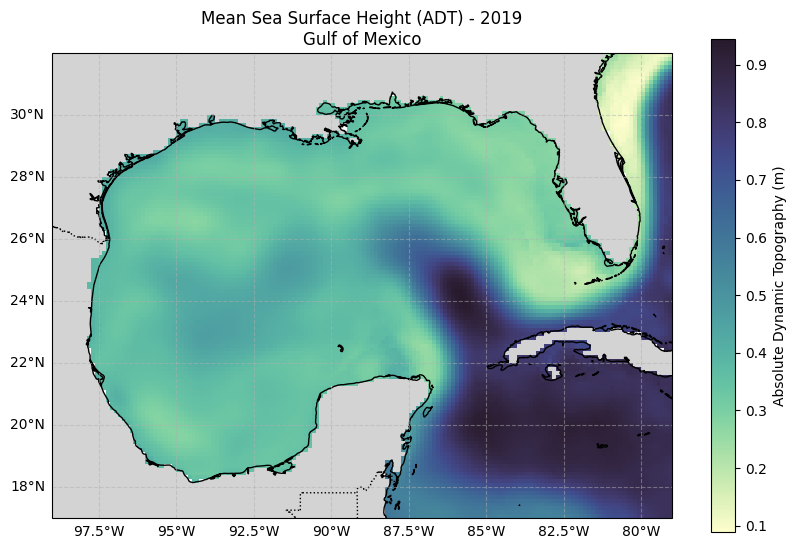

In [12]:
# Calculate temporal mean and Plot
if ds_ssh:
    # Calculate mean over time
    ssh_mean = ds_ssh['adt'].mean(dim='time', keep_attrs=True)

    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Get extent from data
    lon = ssh_mean.lon
    lat = ssh_mean.lat
    # extent = [lon.min(), lon.max(), lat.min(), lat.max()] # Optional, pcolormesh handles it
    
    im = ax.pcolormesh(lon, lat, ssh_mean, 
                       transform=ccrs.PlateCarree(), 
                       cmap=cmocean.cm.deep, 
                       shading='auto')
    
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    
    plt.colorbar(im, label='Absolute Dynamic Topography (m)', shrink=0.8)
    plt.title(f'Mean Sea Surface Height (ADT) - 2019\nGulf of Mexico')
    plt.show()